## 联合分布和跨特征依赖关系
### real / gen 的(pkt_len, iat)二维联合分布热图以及JS散度和Wasserstein distance
如何评估(pkt_len,iat) 的联合分布与跨特征关系？
给我一套 针对 (pkt_len, iat) 的完整 Python 评估代码，其中 pkt_len 建议归一化，iat 建议先 log1p 再归一化，包含
2D 联合分布热图/直方图和2D 距离指标（2D-JSD和2D-Wasserstein distance）

In [16]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist
from scipy.optimize import linprog
from scipy.stats import entropy
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif


In [9]:
#D:\PycharmProjects\My_Paper_exe\Diffusion-Transformer
seq_len = 10000
base_dir = Path.cwd().parent
real_data_path = base_dir / "Data" / "datasets" / "traffic_data" / "data1" / "data.csv"
gen_data_path = base_dir / "Data" / "datasets" / "traffic_data" / "data2" / "data.csv"
#gen_data_path = base_dir / "OUTPUT" / "traffic_1" / "features" / "data_2.csv"
real_df = pd.read_csv(real_data_path, header=0)
real_df.drop(real_df.columns[0], axis=1, inplace=True)
#(117517, 3) int64
real_data = real_df.values
real_pkt_len = real_data[0:seq_len, 0]
real_iat = real_data[0:seq_len, 1]
real_dir = real_data[0:seq_len, 2]

gen_df = pd.read_csv(gen_data_path, header=0)
gen_df.drop(gen_df.columns[0], axis=1, inplace=True)
#(117517, 3) int64
gen_data = gen_df.values
gen_pkt_len = gen_data[0:seq_len, 0]
gen_iat = gen_data[0:seq_len, 1]
gen_dir = gen_data[0:seq_len, 2]

In [10]:

# =========================
# 1. 预处理
# =========================
def minmax_fit(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float64)
    xmin = np.min(x)
    xmax = np.max(x)
    scale = max(xmax - xmin, eps)
    return xmin, xmax, scale


def minmax_transform(x, xmin, xmax, scale):
    x = np.asarray(x, dtype=np.float64)
    return (x - xmin) / scale


def preprocess_pkt_len_iat(real_pkt_len, real_iat, gen_pkt_len, gen_iat, clip_iat_min=0.0):
    """
    对 real/gen 的 pkt_len 和 iat 做统一预处理：
    - pkt_len: Min-Max -> [0,1]
    - iat: clip到非负后 log1p，再 Min-Max -> [0,1]

    归一化参数由 real+gen 合并后共同拟合，保证可比性。
    """
    real_pkt_len = np.asarray(real_pkt_len, dtype=np.float64).reshape(-1)
    real_iat = np.asarray(real_iat, dtype=np.float64).reshape(-1)
    gen_pkt_len = np.asarray(gen_pkt_len, dtype=np.float64).reshape(-1)
    gen_iat = np.asarray(gen_iat, dtype=np.float64).reshape(-1)

    assert len(real_pkt_len) == len(real_iat), "real_pkt_len 和 real_iat 长度必须一致"
    assert len(gen_pkt_len) == len(gen_iat), "gen_pkt_len 和 gen_iat 长度必须一致"

    # iat 理论上应非负；若有微小负值，先裁剪
    real_iat = np.clip(real_iat, clip_iat_min, None)
    gen_iat = np.clip(gen_iat, clip_iat_min, None)

    # iat: log1p
    real_iat_log = np.log1p(real_iat)
    gen_iat_log = np.log1p(gen_iat)

    # 用 real+gen 一起拟合归一化参数
    all_pkt = np.concatenate([real_pkt_len, gen_pkt_len], axis=0)
    all_iat_log = np.concatenate([real_iat_log, gen_iat_log], axis=0)

    pkt_xmin, pkt_xmax, pkt_scale = minmax_fit(all_pkt)
    iat_xmin, iat_xmax, iat_scale = minmax_fit(all_iat_log)

    real_pkt_norm = minmax_transform(real_pkt_len, pkt_xmin, pkt_xmax, pkt_scale)
    gen_pkt_norm = minmax_transform(gen_pkt_len, pkt_xmin, pkt_xmax, pkt_scale)

    real_iat_norm = minmax_transform(real_iat_log, iat_xmin, iat_xmax, iat_scale)
    gen_iat_norm = minmax_transform(gen_iat_log, iat_xmin, iat_xmax, iat_scale)

    stats = {
        "pkt_len_min": pkt_xmin,
        "pkt_len_max": pkt_xmax,
        "iat_log_min": iat_xmin,
        "iat_log_max": iat_xmax,
    }

    return real_pkt_norm, real_iat_norm, gen_pkt_norm, gen_iat_norm, stats


# =========================
# 2. 2D 直方图 / 联合分布
# =========================
def compute_2d_hist(x, y, bins=40, hist_range=((0, 1), (0, 1)), density=True):
    """
    返回:
    - H: shape [bins_x, bins_y]
    - x_edges
    - y_edges
    """
    H, x_edges, y_edges = np.histogram2d(
        x, y,
        bins=bins,
        range=hist_range,
        density=density
    )

    # 为了后续做概率分布比较，统一归一化成 sum=1
    H = H.astype(np.float64)
    H_sum = H.sum()
    if H_sum > 0:
        H = H / H_sum
    return H, x_edges, y_edges


# =========================
# 3. 2D-JSD
# =========================
def kl_divergence(p, q, eps=1e-12):
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)

    p = p + eps
    q = q + eps

    p = p / p.sum()
    q = q / q.sum()

    return np.sum(p * np.log(p / q))


def js_divergence_2d(H_real, H_gen, eps=1e-12):
    """
    输入为二维概率直方图，返回 JSD
    """
    p = H_real.reshape(-1)
    q = H_gen.reshape(-1)

    p = p + eps
    q = q + eps
    p = p / p.sum()
    q = q / q.sum()

    m = 0.5 * (p + q)
    jsd = 0.5 * kl_divergence(p, m, eps=eps) + 0.5 * kl_divergence(q, m, eps=eps)
    return jsd


# =========================
# 4. 2D Wasserstein
# =========================
def get_hist_bin_centers(x_edges, y_edges):
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
    xx, yy = np.meshgrid(x_centers, y_centers, indexing="ij")
    coords = np.stack([xx.ravel(), yy.ravel()], axis=1)  # [n_bins, 2]
    return coords


def sinkhorn_distance(a, b, M, reg=0.01, num_iters=500, tol=1e-9):
    """
    计算离散分布 a, b 在代价矩阵 M 下的 Sinkhorn 正则化 OT 距离
    a, b: shape [n], sum=1
    M: shape [n, n]
    返回: transport_cost
    """
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    M = np.asarray(M, dtype=np.float64)

    a = a / a.sum()
    b = b / b.sum()

    # K = exp(-M / reg)
    K = np.exp(-M / reg) + 1e-300

    u = np.ones_like(a)
    v = np.ones_like(b)

    for _ in range(num_iters):
        u_prev = u.copy()
        Kv = K @ v + 1e-300
        u = a / Kv
        KTu = K.T @ u + 1e-300
        v = b / KTu

        if np.max(np.abs(u - u_prev)) < tol:
            break

    # 运输矩阵
    T = (u[:, None] * K) * v[None, :]
    cost = np.sum(T * M)
    return cost


def wasserstein_2d_from_hist(H_real, H_gen, x_edges, y_edges, use_pot_if_available=True, sinkhorn_reg=0.01):
    """
    基于二维直方图离散分布计算 2D Wasserstein distance

    优先：
    - 如果安装了 POT，则用 ot.emd2 / ot.sinkhorn2
    否则：
    - 用本地 Sinkhorn 实现

    返回:
    - wd: float
    - method: str
    """
    a = H_real.reshape(-1).astype(np.float64)
    b = H_gen.reshape(-1).astype(np.float64)

    # bin center 坐标
    coords = get_hist_bin_centers(x_edges, y_edges)

    # 欧氏距离作为地面代价
    M = cdist(coords, coords, metric="euclidean")

    # 归一化代价矩阵，有助于 Sinkhorn 稳定
    M = M / (M.max() + 1e-12)

    if use_pot_if_available:
        try:
            import ot  # pip install pot

            a_ = a / (a.sum() + 1e-12)
            b_ = b / (b.sum() + 1e-12)

            # 先尝试精确 EMD
            wd = ot.emd2(a_, b_, M)
            return float(wd), "POT exact EMD"
        except Exception:
            pass

    # fallback: Sinkhorn
    wd = sinkhorn_distance(a, b, M, reg=sinkhorn_reg)
    return float(wd), f"Sinkhorn(reg={sinkhorn_reg})"


# =========================
# 5. 可视化
# =========================
def plot_joint_heatmaps(H_real, H_gen, x_edges, y_edges, title_prefix="(pkt_len, iat)"):
    """
    展示 real / gen 的二维联合分布热图
    """
    extent = [x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    im0 = axes[0].imshow(
        H_real.T,
        origin="lower",
        aspect="auto",
        extent=extent
    )
    axes[0].set_title(f"{title_prefix} - Real 2D Histogram")
    axes[0].set_xlabel("pkt_len (normalized)")
    axes[0].set_ylabel("iat (log1p + normalized)")
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(
        H_gen.T,
        origin="lower",
        aspect="auto",
        extent=extent
    )
    axes[1].set_title(f"{title_prefix} - Generated 2D Histogram")
    axes[1].set_xlabel("pkt_len (normalized)")
    axes[1].set_ylabel("iat (log1p + normalized)")
    plt.colorbar(im1, ax=axes[1])

    plt.tight_layout()
    plt.show()


def plot_difference_heatmap(H_real, H_gen, x_edges, y_edges, title="Real - Generated"):
    """
    展示差异热图
    """
    diff = H_real - H_gen
    extent = [x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]]

    plt.figure(figsize=(6, 5))
    plt.imshow(
        diff.T,
        origin="lower",
        aspect="auto",
        extent=extent
    )
    plt.title(title)
    plt.xlabel("pkt_len (normalized)")
    plt.ylabel("iat (log1p + normalized)")
    plt.colorbar(label="Probability Difference")
    plt.tight_layout()
    plt.show()


# =========================
# 6. 主评估函数
# =========================
def evaluate_joint_pktlen_iat(
    real_pkt_len,
    real_iat,
    gen_pkt_len,
    gen_iat,
    bins=40,
    hist_range=((0, 1), (0, 1)),
    use_pot_if_available=True,
    sinkhorn_reg=0.01,
    plot=True
):
    """
    完整评估入口：
    - 预处理
    - 2D histogram
    - 2D-JSD
    - 2D-Wasserstein
    - 可视化

    返回:
    results: dict
    """
    # 1) 预处理
    real_pkt_norm, real_iat_norm, gen_pkt_norm, gen_iat_norm, stats = preprocess_pkt_len_iat(
        real_pkt_len, real_iat, gen_pkt_len, gen_iat
    )

    # 2) 2D 直方图
    H_real, x_edges, y_edges = compute_2d_hist(
        real_pkt_norm, real_iat_norm, bins=bins, hist_range=hist_range, density=True
    )
    H_gen, _, _ = compute_2d_hist(
        gen_pkt_norm, gen_iat_norm, bins=bins, hist_range=hist_range, density=True
    )

    # 3) 2D-JSD
    jsd_2d = js_divergence_2d(H_real, H_gen)

    # 4) 2D-Wasserstein
    wasserstein_2d, wd_method = wasserstein_2d_from_hist(
        H_real, H_gen, x_edges, y_edges,
        use_pot_if_available=use_pot_if_available,
        sinkhorn_reg=sinkhorn_reg
    )

    results = {
        "2D_JSD": jsd_2d,
        "2D_Wasserstein": wasserstein_2d,
        "Wasserstein_method": wd_method,
        "real_hist": H_real,
        "gen_hist": H_gen,
        "x_edges": x_edges,
        "y_edges": y_edges,
        "preprocess_stats": stats,
        "real_pkt_norm": real_pkt_norm,
        "real_iat_norm": real_iat_norm,
        "gen_pkt_norm": gen_pkt_norm,
        "gen_iat_norm": gen_iat_norm,
    }

    if plot:
        plot_joint_heatmaps(H_real, H_gen, x_edges, y_edges, title_prefix="(pkt_len, iat)")
        plot_difference_heatmap(H_real, H_gen, x_edges, y_edges)

    return results




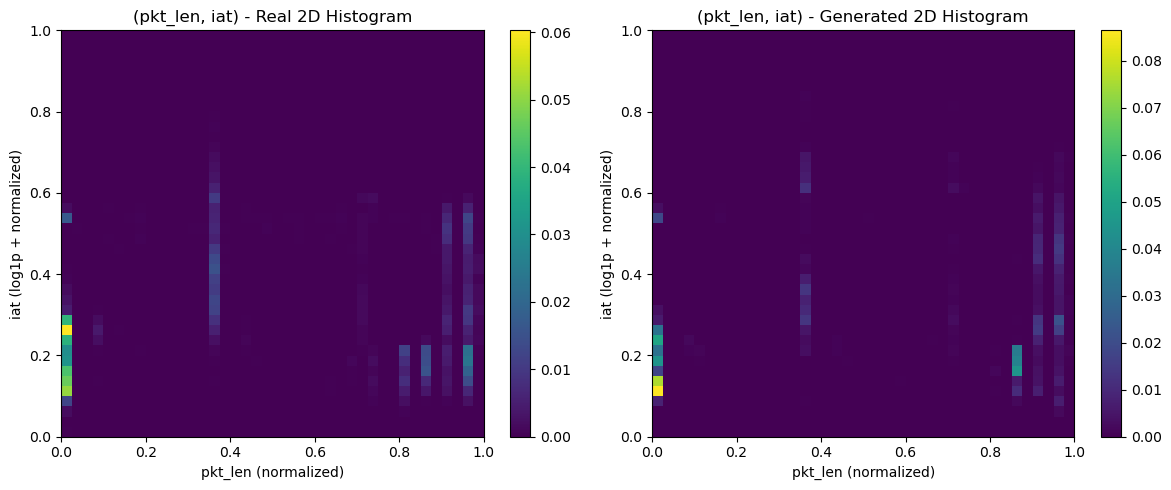

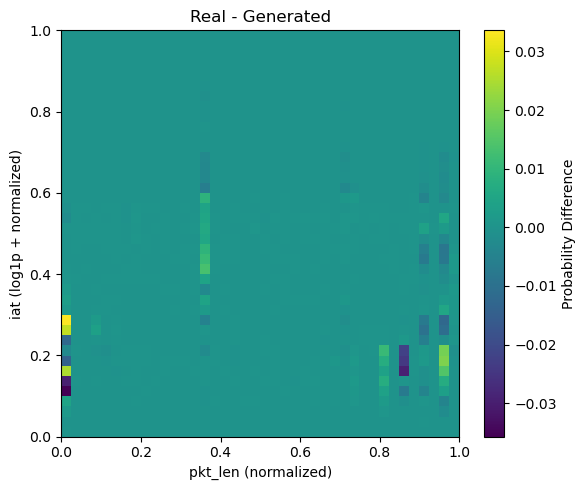


===== Evaluation Results =====
2D-JSD                : 0.115547
2D-Wasserstein        : 0.042990
Wasserstein method    : Sinkhorn(reg=0.01)
Preprocess stats      : {'pkt_len_min': 20.0, 'pkt_len_max': 1480.0, 'iat_log_min': 0.0, 'iat_log_max': 19.247686721034327}


In [11]:
# -------- 运行评估 --------
results = evaluate_joint_pktlen_iat(
        real_pkt_len=real_pkt_len,
        real_iat=real_iat,
        gen_pkt_len=gen_pkt_len,
        gen_iat=gen_iat,
        bins=40,
        use_pot_if_available=True,
        sinkhorn_reg=0.01,
        plot=True
    )

print("\n===== Evaluation Results =====")
print(f"2D-JSD                : {results['2D_JSD']:.6f}")
print(f"2D-Wasserstein        : {results['2D_Wasserstein']:.6f}")
print(f"Wasserstein method    : {results['Wasserstein_method']}")
print("Preprocess stats      :", results["preprocess_stats"])

## (pkt_len, iat, dir)的三维联合分布（MMD）&条件二维联合分布
其中对 (pkt_len, iat, dir)，pkt_len 建议归一化，iat 建议先 log1p 再归一化，dir 保持离散编码，包含：三维 MMD，Wasserstein 距离（作用在三维样本点上）
按 dir 条件划分后的 2D heatmap 与2D MMD， Wasserstein distance，JSD

In [12]:
# =========================================================
# 1. 预处理
# =========================================================
def fit_preprocessors(real_data):
    """
    仅使用真实数据拟合 scaler，避免信息泄漏
    real_data: ndarray, shape (N, 3), columns = [pkt_len, iat, dir]
    """
    pkt_len_real = real_data[:, 0].reshape(-1, 1)
    iat_real = real_data[:, 1].reshape(-1, 1)

    # pkt_len: MinMax
    pkt_scaler = MinMaxScaler()
    pkt_scaler.fit(pkt_len_real)

    # iat: log1p 后 MinMax
    iat_log_real = np.log1p(np.clip(iat_real, a_min=0, a_max=None))
    iat_scaler = MinMaxScaler()
    iat_scaler.fit(iat_log_real)

    return pkt_scaler, iat_scaler


def transform_data(data, pkt_scaler, iat_scaler):
    """
    返回预处理后的三维数据:
    [pkt_len_norm, iat_log_norm, dir]
    """
    pkt_len = data[:, 0].reshape(-1, 1)
    iat = data[:, 1].reshape(-1, 1)
    direction = data[:, 2].reshape(-1, 1)

    pkt_len_norm = pkt_scaler.transform(pkt_len)
    iat_log = np.log1p(np.clip(iat, a_min=0, a_max=None))
    iat_norm = iat_scaler.transform(iat_log)

    processed = np.hstack([pkt_len_norm, iat_norm, direction])
    return processed


# =========================================================
# 2. MMD
# =========================================================
def median_heuristic_sigma(X, Y):
    """
    用合并样本的中位数距离估计 RBF 核宽度
    """
    Z = np.vstack([X, Y])
    if len(Z) > 3000:
        idx = np.random.choice(len(Z), size=3000, replace=False)
        Z = Z[idx]
    D = cdist(Z, Z, metric='euclidean')
    D = D[np.triu_indices_from(D, k=1)]
    D = D[D > 0]
    if len(D) == 0:
        return 1.0
    return np.median(D)


def rbf_kernel(X, Y, sigma):
    d2 = cdist(X, Y, metric='sqeuclidean')
    K = np.exp(-d2 / (2 * sigma ** 2 + 1e-12))
    return K


def compute_mmd_rbf(X, Y, sigma=None):
    """
    无偏近似的 biased MMD^2（常用于生成评估，稳定）
    返回 MMD（开方后）
    """
    if sigma is None:
        sigma = median_heuristic_sigma(X, Y)

    Kxx = rbf_kernel(X, X, sigma)
    Kyy = rbf_kernel(Y, Y, sigma)
    Kxy = rbf_kernel(X, Y, sigma)

    mmd2 = Kxx.mean() + Kyy.mean() - 2 * Kxy.mean()
    mmd2 = max(mmd2, 0.0)
    return np.sqrt(mmd2), sigma


# =========================================================
# 3. Wasserstein distance（经验分布上的 OT）
# =========================================================
def subsample_equal(X, Y, max_samples=300):
    """
    为了控制 OT 计算复杂度，随机下采样
    """
    n = min(len(X), len(Y), max_samples)
    idx_x = np.random.choice(len(X), size=n, replace=False)
    idx_y = np.random.choice(len(Y), size=n, replace=False)
    return X[idx_x], Y[idx_y]


def compute_wasserstein_distance_empirical(X, Y, p=1, max_samples=200):
    """
    在样本点上计算经验分布 Wasserstein distance
    - 默认使用等权重经验分布
    - 用线性规划求最优传输
    - 复杂度较高，所以建议下采样

    返回:
        W_p 距离
    """
    Xs, Ys = subsample_equal(X, Y, max_samples=max_samples)
    n = len(Xs)
    m = len(Ys)

    # cost matrix
    C = cdist(Xs, Ys, metric='euclidean') ** p
    c = C.flatten()

    # 变量是 transport plan gamma_{ij}, 共 n*m 个
    # 约束:
    # 每行和 = 1/n
    # 每列和 = 1/m
    A_eq = []
    b_eq = []

    # row constraints
    for i in range(n):
        row = np.zeros(n * m)
        row[i * m:(i + 1) * m] = 1.0
        A_eq.append(row)
        b_eq.append(1.0 / n)

    # col constraints
    for j in range(m):
        col = np.zeros(n * m)
        col[j::m] = 1.0
        A_eq.append(col)
        b_eq.append(1.0 / m)

    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)

    bounds = [(0, None)] * (n * m)

    res = linprog(
        c=c,
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=bounds,
        method='highs'
    )

    if not res.success:
        raise RuntimeError(f"Linear programming failed: {res.message}")

    transport_cost = res.fun
    wasserstein_p = transport_cost ** (1.0 / p)
    return wasserstein_p


# =========================================================
# 4. 2D Histogram + JSD
# =========================================================
def compute_2d_histogram(X2, bins=40, range_2d=((0, 1), (0, 1))):
    """
    X2: shape (N, 2), columns = [pkt_len_norm, iat_norm]
    """
    H, xedges, yedges = np.histogram2d(
        X2[:, 0], X2[:, 1],
        bins=bins,
        range=range_2d,
        density=False
    )
    H = H.astype(np.float64)
    H = H / (H.sum() + 1e-12)
    return H, xedges, yedges


def compute_jsd_from_2d_hist(H_real, H_gen, eps=1e-12):
    """
    对 2D histogram flatten 后计算 JSD
    """
    p = H_real.flatten() + eps
    q = H_gen.flatten() + eps
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)
    jsd = 0.5 * entropy(p, m) + 0.5 * entropy(q, m)
    return jsd


# =========================================================
# 5. 条件评估与可视化
# =========================================================
def plot_2d_heatmaps(real_2d, gen_2d, dir_value, bins=40):
    """
    画按 dir 条件划分后的二维热图
    """
    H_real, _, _ = compute_2d_histogram(real_2d, bins=bins)
    H_gen, _, _ = compute_2d_histogram(gen_2d, bins=bins)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    im0 = axes[0].imshow(
        H_real.T,
        origin='lower',
        aspect='auto',
        extent=[0, 1, 0, 1]
    )
    axes[0].set_title(f"Real 2D Heatmap | dir={dir_value}")
    axes[0].set_xlabel("pkt_len_norm")
    axes[0].set_ylabel("iat_log_norm")
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(
        H_gen.T,
        origin='lower',
        aspect='auto',
        extent=[0, 1, 0, 1]
    )
    axes[1].set_title(f"Generated 2D Heatmap | dir={dir_value}")
    axes[1].set_xlabel("pkt_len_norm")
    axes[1].set_ylabel("iat_log_norm")
    plt.colorbar(im1, ax=axes[1])

    plt.tight_layout()
    plt.show()


def evaluate_conditional_2d(real_proc, gen_proc, dir_value, bins=40,
                            max_samples_mmd=2000, max_samples_wd=200):
    """
    对固定 dir 条件下的 (pkt_len_norm, iat_log_norm) 做:
    - heatmap
    - 2D MMD
    - 2D Wasserstein
    - 2D JSD
    """
    real_cond = real_proc[real_proc[:, 2] == dir_value][:, :2]
    gen_cond = gen_proc[gen_proc[:, 2] == dir_value][:, :2]

    if len(real_cond) == 0 or len(gen_cond) == 0:
        print(f"[Warning] dir={dir_value} 在 real 或 gen 中没有样本，跳过。")
        return None

    # 可视化
    plot_2d_heatmaps(real_cond, gen_cond, dir_value=dir_value, bins=bins)

    # 为控制复杂度，可对子样本做 MMD
    if len(real_cond) > max_samples_mmd:
        idx = np.random.choice(len(real_cond), size=max_samples_mmd, replace=False)
        real_mmd = real_cond[idx]
    else:
        real_mmd = real_cond

    if len(gen_cond) > max_samples_mmd:
        idx = np.random.choice(len(gen_cond), size=max_samples_mmd, replace=False)
        gen_mmd = gen_cond[idx]
    else:
        gen_mmd = gen_cond

    mmd_2d, sigma_2d = compute_mmd_rbf(real_mmd, gen_mmd, sigma=None)

    # 2D Wasserstein
    wd_2d = compute_wasserstein_distance_empirical(
        real_cond, gen_cond, p=1, max_samples=max_samples_wd
    )

    # 2D JSD
    H_real, _, _ = compute_2d_histogram(real_cond, bins=bins)
    H_gen, _, _ = compute_2d_histogram(gen_cond, bins=bins)
    jsd_2d = compute_jsd_from_2d_hist(H_real, H_gen)

    result = {
        "dir": dir_value,
        "num_real": len(real_cond),
        "num_gen": len(gen_cond),
        "mmd_2d": mmd_2d,
        "mmd_sigma_2d": sigma_2d,
        "wasserstein_2d": wd_2d,
        "jsd_2d": jsd_2d
    }
    return result


# =========================================================
# 6. 主评估函数
# =========================================================
def evaluate_joint_distribution(
    real_data,
    gen_data,
    bins=40,
    max_samples_mmd_3d=2000,
    max_samples_wd_3d=200,
    max_samples_mmd_2d=2000,
    max_samples_wd_2d=200
):
    """
    主函数:
    1) 预处理
    2) 三维 MMD
    3) 三维 Wasserstein
    4) 按 dir 条件划分后的 2D heatmap / MMD / Wasserstein / JSD
    """
    # ---------- 预处理 ----------
    pkt_scaler, iat_scaler = fit_preprocessors(real_data)
    real_proc = transform_data(real_data, pkt_scaler, iat_scaler)
    gen_proc = transform_data(gen_data, pkt_scaler, iat_scaler)

    # ---------- 三维 MMD ----------
    if len(real_proc) > max_samples_mmd_3d:
        idx = np.random.choice(len(real_proc), size=max_samples_mmd_3d, replace=False)
        real_3d_mmd = real_proc[idx]
    else:
        real_3d_mmd = real_proc

    if len(gen_proc) > max_samples_mmd_3d:
        idx = np.random.choice(len(gen_proc), size=max_samples_mmd_3d, replace=False)
        gen_3d_mmd = gen_proc[idx]
    else:
        gen_3d_mmd = gen_proc

    mmd_3d, sigma_3d = compute_mmd_rbf(real_3d_mmd, gen_3d_mmd, sigma=None)

    # ---------- 三维 Wasserstein ----------
    wd_3d = compute_wasserstein_distance_empirical(
        real_proc, gen_proc, p=1, max_samples=max_samples_wd_3d
    )

    # ---------- 条件 2D ----------
    unique_dirs = np.union1d(np.unique(real_proc[:, 2]), np.unique(gen_proc[:, 2]))

    conditional_results = []
    for d in unique_dirs:
        result = evaluate_conditional_2d(
            real_proc=real_proc,
            gen_proc=gen_proc,
            dir_value=d,
            bins=bins,
            max_samples_mmd=max_samples_mmd_2d,
            max_samples_wd=max_samples_wd_2d
        )
        if result is not None:
            conditional_results.append(result)

    # ---------- 汇总 ----------
    summary = {
        "mmd_3d": mmd_3d,
        "mmd_sigma_3d": sigma_3d,
        "wasserstein_3d": wd_3d,
        "conditional_results": conditional_results,
        "real_processed": real_proc,
        "gen_processed": gen_proc
    }

    return summary

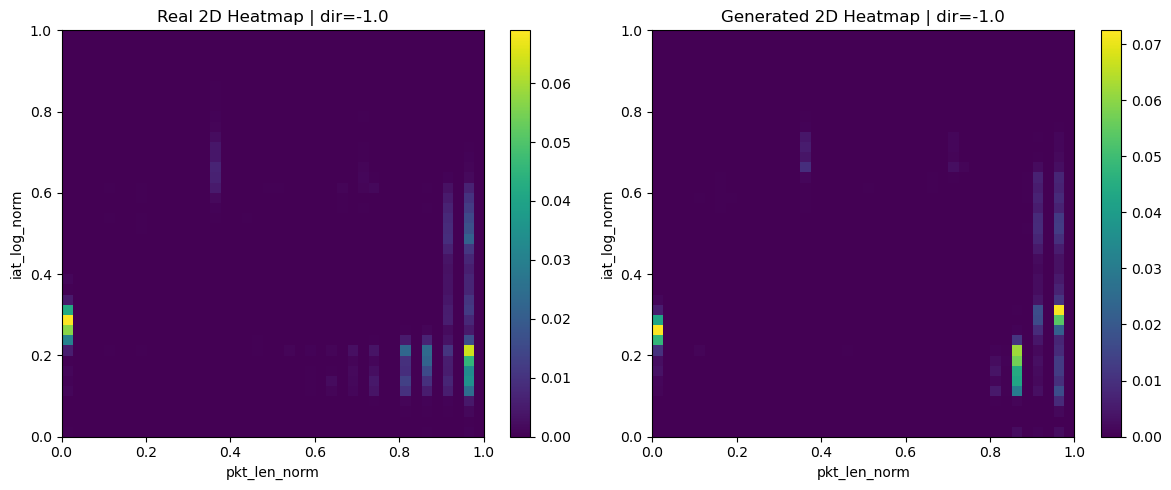

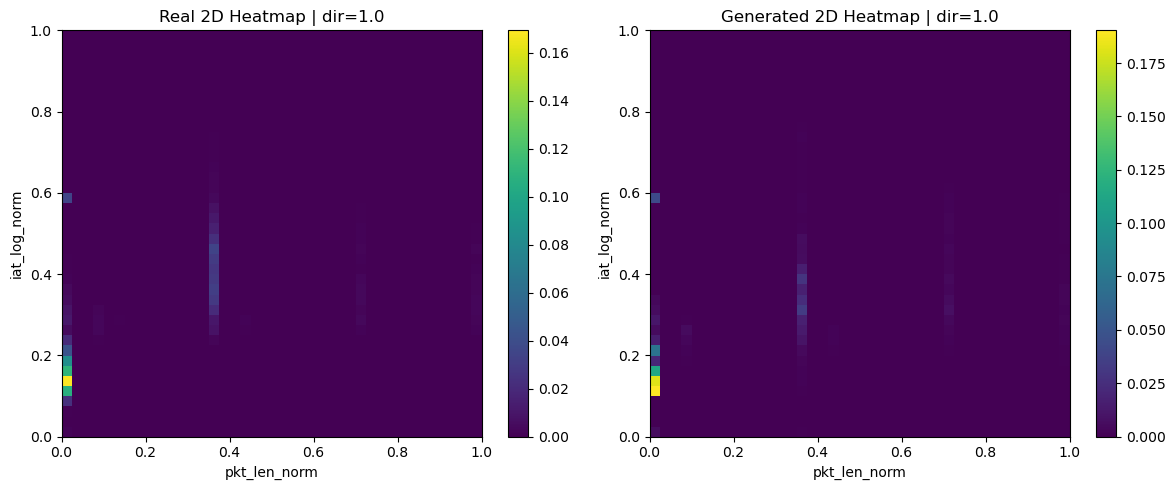


========== Global 3D Metrics ==========
3D MMD                 : 0.025704
3D MMD sigma           : 0.986045
3D Wasserstein Distance: 0.087880

========== Conditional 2D Metrics ==========

dir = -1.0
num_real         : 30929
num_gen          : 30702
2D MMD           : 0.070168
2D MMD sigma     : 0.361023
2D Wasserstein   : 0.088692
2D JSD           : 0.140756

dir = 1.0
num_real         : 19071
num_gen          : 19298
2D MMD           : 0.076663
2D MMD sigma     : 0.378961
2D Wasserstein   : 0.042619
2D JSD           : 0.069590


In [15]:
real_data = real_data[0:50000,:]
gen_data = gen_data[0:50000,:]
results = evaluate_joint_distribution(
        real_data=real_data,
        gen_data=gen_data,
        bins=40,
        max_samples_mmd_3d=1500,
        max_samples_wd_3d=150,
        max_samples_mmd_2d=1500,
        max_samples_wd_2d=150
)

print("\n========== Global 3D Metrics ==========")
print(f"3D MMD                 : {results['mmd_3d']:.6f}")
print(f"3D MMD sigma           : {results['mmd_sigma_3d']:.6f}")
print(f"3D Wasserstein Distance: {results['wasserstein_3d']:.6f}")

print("\n========== Conditional 2D Metrics ==========")
for r in results["conditional_results"]:
    print(f"\ndir = {r['dir']}")
    print(f"num_real         : {r['num_real']}")
    print(f"num_gen          : {r['num_gen']}")
    print(f"2D MMD           : {r['mmd_2d']:.6f}")
    print(f"2D MMD sigma     : {r['mmd_sigma_2d']:.6f}")
    print(f"2D Wasserstein   : {r['wasserstein_2d']:.6f}")
    print(f"2D JSD           : {r['jsd_2d']:.6f}")

## 跨特征依赖关系

In [17]:

# =========================================================
# 1. 预处理
# =========================================================
def fit_preprocessors(real_data):
    pkt_len_real = real_data[:, 0].reshape(-1, 1)
    iat_real = real_data[:, 1].reshape(-1, 1)

    pkt_scaler = MinMaxScaler()
    pkt_scaler.fit(pkt_len_real)

    iat_log_real = np.log1p(np.clip(iat_real, a_min=0, a_max=None))
    iat_scaler = MinMaxScaler()
    iat_scaler.fit(iat_log_real)

    return pkt_scaler, iat_scaler


def transform_data(data, pkt_scaler, iat_scaler):
    pkt_len = data[:, 0].reshape(-1, 1)
    iat = data[:, 1].reshape(-1, 1)
    direction = data[:, 2].reshape(-1, 1)

    pkt_len_norm = pkt_scaler.transform(pkt_len)
    iat_log = np.log1p(np.clip(iat, a_min=0, a_max=None))
    iat_norm = iat_scaler.transform(iat_log)

    return np.hstack([pkt_len_norm, iat_norm, direction])


# =========================================================
# 2. 相关矩阵
# =========================================================
def compute_pearson_matrix(X):
    """
    X: shape (N, d)
    return: (d, d)
    """
    d = X.shape[1]
    corr = np.zeros((d, d), dtype=float)

    for i in range(d):
        for j in range(d):
            if i == j:
                corr[i, j] = 1.0
            else:
                corr[i, j] = pearsonr(X[:, i], X[:, j])[0]
    return corr


def compute_spearman_matrix(X):
    d = X.shape[1]
    corr = np.zeros((d, d), dtype=float)

    for i in range(d):
        for j in range(d):
            if i == j:
                corr[i, j] = 1.0
            else:
                corr[i, j] = spearmanr(X[:, i], X[:, j])[0]
    return corr


def matrix_difference_summary(A, B):
    """
    比较两个依赖矩阵，仅统计上三角（不含对角）
    """
    d = A.shape[0]
    vals = []
    for i in range(d):
        for j in range(i + 1, d):
            vals.append(abs(A[i, j] - B[i, j]))
    vals = np.array(vals)

    return {
        "mean_abs_diff": vals.mean(),
        "max_abs_diff": vals.max(),
        "fro_norm": np.linalg.norm(A - B, ord='fro')
    }


# =========================================================
# 3. Mutual Information 矩阵
# =========================================================
def compute_mi_pair(x, y, x_discrete=False, y_discrete=False, random_state=42):
    """
    计算两个变量之间的 MI
    这里统一用 sklearn 的估计方式做近似

    情况分为：
    - y 连续: 用 mutual_info_regression
    - y 离散: 用 mutual_info_classif

    输入 x 作为 feature，y 作为 target
    """
    x = np.asarray(x).reshape(-1, 1)
    y = np.asarray(y)

    if y_discrete:
        mi = mutual_info_classif(
            x, y,
            discrete_features=[x_discrete],
            random_state=random_state
        )[0]
    else:
        mi = mutual_info_regression(
            x, y,
            discrete_features=[x_discrete],
            random_state=random_state
        )[0]
    return mi


def compute_mi_matrix(X, discrete_mask, random_state=42):
    """
    X: shape (N, d)
    discrete_mask: list/array of bool, 长度 d
        True 表示离散变量，False 表示连续变量

    返回:
        对称 MI 矩阵
    """
    d = X.shape[1]
    M = np.zeros((d, d), dtype=float)

    for i in range(d):
        for j in range(d):
            if i == j:
                M[i, j] = 0.0
            elif i < j:
                mi_ij = compute_mi_pair(
                    X[:, i], X[:, j],
                    x_discrete=discrete_mask[i],
                    y_discrete=discrete_mask[j],
                    random_state=random_state
                )
                mi_ji = compute_mi_pair(
                    X[:, j], X[:, i],
                    x_discrete=discrete_mask[j],
                    y_discrete=discrete_mask[i],
                    random_state=random_state
                )
                # 为减少非对称估计误差，取平均
                mi = 0.5 * (mi_ij + mi_ji)
                M[i, j] = mi
                M[j, i] = mi

    return M


# =========================================================
# 4. 条件依赖结构
# =========================================================
def compute_conditional_dependency(real_proc, gen_proc, dir_value):
    """
    在固定 dir 条件下，只看 (pkt_len_norm, iat_norm)
    """
    real_cond = real_proc[real_proc[:, 2] == dir_value][:, :2]
    gen_cond = gen_proc[gen_proc[:, 2] == dir_value][:, :2]

    if len(real_cond) < 3 or len(gen_cond) < 3:
        return None

    # Pearson
    real_pearson = pearsonr(real_cond[:, 0], real_cond[:, 1])[0]
    gen_pearson = pearsonr(gen_cond[:, 0], gen_cond[:, 1])[0]

    # Spearman
    real_spearman = spearmanr(real_cond[:, 0], real_cond[:, 1])[0]
    gen_spearman = spearmanr(gen_cond[:, 0], gen_cond[:, 1])[0]

    # MI
    real_mi = compute_mi_pair(
        real_cond[:, 0], real_cond[:, 1],
        x_discrete=False, y_discrete=False
    )
    gen_mi = compute_mi_pair(
        gen_cond[:, 0], gen_cond[:, 1],
        x_discrete=False, y_discrete=False
    )

    return {
        "dir": dir_value,
        "real_count": len(real_cond),
        "gen_count": len(gen_cond),
        "real_pearson": real_pearson,
        "gen_pearson": gen_pearson,
        "pearson_abs_diff": abs(real_pearson - gen_pearson),
        "real_spearman": real_spearman,
        "gen_spearman": gen_spearman,
        "spearman_abs_diff": abs(real_spearman - gen_spearman),
        "real_mi": real_mi,
        "gen_mi": gen_mi,
        "mi_abs_diff": abs(real_mi - gen_mi),
    }


# =========================================================
# 5. 可视化
# =========================================================
def plot_matrix(mat, title, labels):
    plt.figure(figsize=(5, 4))
    plt.imshow(mat, aspect='auto', origin='upper')
    plt.colorbar()
    plt.xticks(range(len(labels)), labels)
    plt.yticks(range(len(labels)), labels)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_difference_matrix(real_mat, gen_mat, title, labels):
    diff = np.abs(real_mat - gen_mat)
    plt.figure(figsize=(5, 4))
    plt.imshow(diff, aspect='auto', origin='upper')
    plt.colorbar()
    plt.xticks(range(len(labels)), labels)
    plt.yticks(range(len(labels)), labels)
    plt.title(title)
    plt.tight_layout()
    plt.show()


# =========================================================
# 6. 主函数
# =========================================================
def evaluate_cross_feature_dependency(real_data, gen_data):
    """
    real_data / gen_data: columns = [pkt_len, iat, dir]
    """
    pkt_scaler, iat_scaler = fit_preprocessors(real_data)
    real_proc = transform_data(real_data, pkt_scaler, iat_scaler)
    gen_proc = transform_data(gen_data, pkt_scaler, iat_scaler)

    labels = ["pkt_len_norm", "iat_log_norm", "dir"]
    discrete_mask = [False, False, True]

    # 1) Pearson
    real_pearson = compute_pearson_matrix(real_proc)
    gen_pearson = compute_pearson_matrix(gen_proc)
    pearson_summary = matrix_difference_summary(real_pearson, gen_pearson)

    # 2) Spearman
    real_spearman = compute_spearman_matrix(real_proc)
    gen_spearman = compute_spearman_matrix(gen_proc)
    spearman_summary = matrix_difference_summary(real_spearman, gen_spearman)

    # 3) MI
    real_mi = compute_mi_matrix(real_proc, discrete_mask=discrete_mask)
    gen_mi = compute_mi_matrix(gen_proc, discrete_mask=discrete_mask)
    mi_summary = matrix_difference_summary(real_mi, gen_mi)

    # 4) 条件依赖
    unique_dirs = np.union1d(np.unique(real_proc[:, 2]), np.unique(gen_proc[:, 2]))
    conditional_results = []
    for d in unique_dirs:
        r = compute_conditional_dependency(real_proc, gen_proc, d)
        if r is not None:
            conditional_results.append(r)

    results = {
        "real_processed": real_proc,
        "gen_processed": gen_proc,

        "real_pearson": real_pearson,
        "gen_pearson": gen_pearson,
        "pearson_summary": pearson_summary,

        "real_spearman": real_spearman,
        "gen_spearman": gen_spearman,
        "spearman_summary": spearman_summary,

        "real_mi": real_mi,
        "gen_mi": gen_mi,
        "mi_summary": mi_summary,

        "conditional_results": conditional_results,
        "labels": labels
    }
    return results





========== Pearson ==========
Real Pearson:
 [[ 1.          0.14850421 -0.59354965]
 [ 0.14850421  1.         -0.09361841]
 [-0.59354965 -0.09361841  1.        ]]
Gen Pearson:
 [[ 1.          0.24283742 -0.62511373]
 [ 0.24283742  1.         -0.18041936]
 [-0.62511373 -0.18041936  1.        ]]
Pearson summary: {'mean_abs_diff': 0.07089941592524379, 'max_abs_diff': 0.09433320777789861, 'fro_norm': 0.18670538779670767}

========== Spearman ==========
Real Spearman:
 [[ 1.          0.16693342 -0.55832349]
 [ 0.16693342  1.         -0.13150468]
 [-0.55832349 -0.13150468  1.        ]]
Gen Spearman:
 [[ 1.          0.34359856 -0.59048797]
 [ 0.34359856  1.         -0.23513845]
 [-0.59048797 -0.23513845  1.        ]]
Spearman summary: {'mean_abs_diff': 0.10415446210771669, 'max_abs_diff': 0.17666514002914274, 'fro_norm': 0.2932066984219097}

========== Mutual Information ==========
Real MI:
 [[0.         0.44184364 0.35436485]
 [0.44184364 0.         0.09101092]
 [0.35436485 0.09101092 0.   

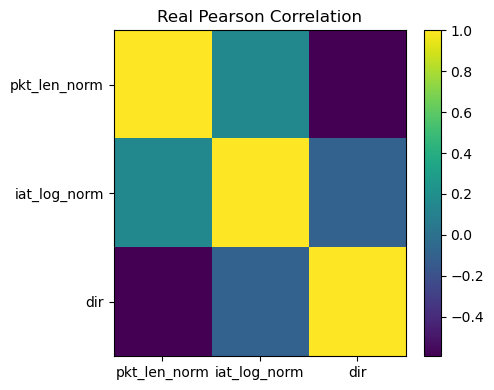

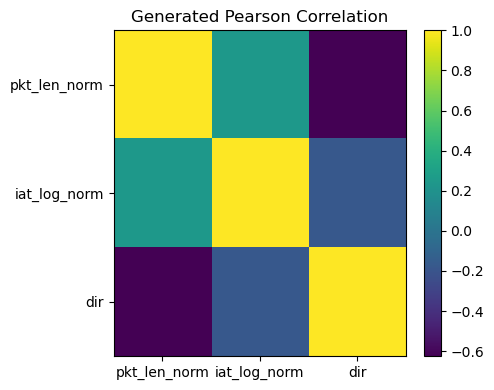

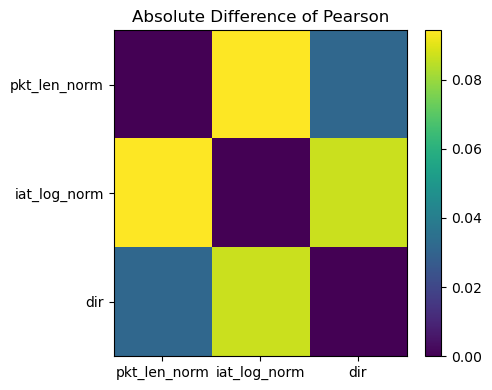

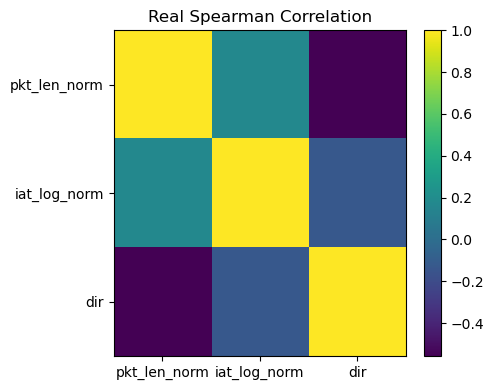

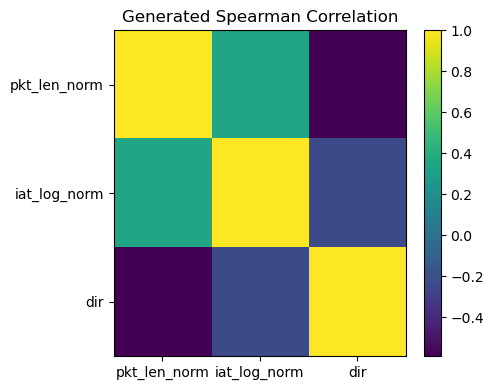

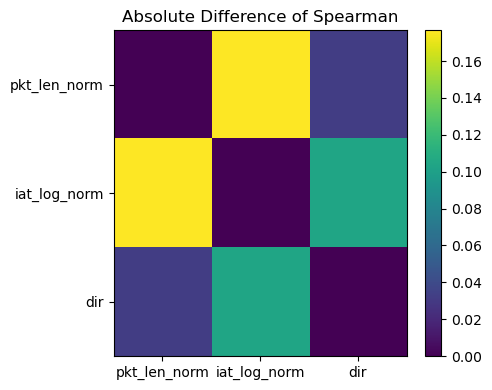

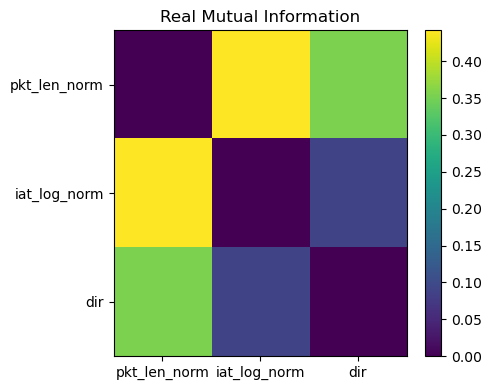

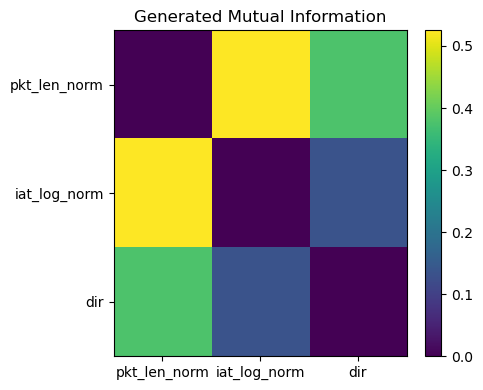

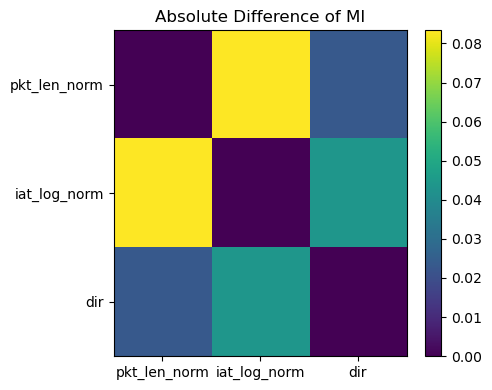

In [19]:
# =========================================================
# 7. 示例
# =========================================================
results = evaluate_cross_feature_dependency(real_data, gen_data)

print("\n========== Pearson ==========")
print("Real Pearson:\n", results["real_pearson"])
print("Gen Pearson:\n", results["gen_pearson"])
print("Pearson summary:", results["pearson_summary"])

print("\n========== Spearman ==========")
print("Real Spearman:\n", results["real_spearman"])
print("Gen Spearman:\n", results["gen_spearman"])
print("Spearman summary:", results["spearman_summary"])

print("\n========== Mutual Information ==========")
print("Real MI:\n", results["real_mi"])
print("Gen MI:\n", results["gen_mi"])
print("MI summary:", results["mi_summary"])

print("\n========== Conditional Dependency ==========")
for r in results["conditional_results"]:
        print(f"\ndir = {r['dir']}")
        print(f"real_count           : {r['real_count']}")
        print(f"gen_count            : {r['gen_count']}")
        print(f"real_pearson         : {r['real_pearson']:.6f}")
        print(f"gen_pearson          : {r['gen_pearson']:.6f}")
        print(f"pearson_abs_diff     : {r['pearson_abs_diff']:.6f}")
        print(f"real_spearman        : {r['real_spearman']:.6f}")
        print(f"gen_spearman         : {r['gen_spearman']:.6f}")
        print(f"spearman_abs_diff    : {r['spearman_abs_diff']:.6f}")
        print(f"real_mi              : {r['real_mi']:.6f}")
        print(f"gen_mi               : {r['gen_mi']:.6f}")
        print(f"mi_abs_diff          : {r['mi_abs_diff']:.6f}")

# 可视化
labels = results["labels"]

plot_matrix(results["real_pearson"], "Real Pearson Correlation", labels)
plot_matrix(results["gen_pearson"], "Generated Pearson Correlation", labels)
plot_difference_matrix(results["real_pearson"], results["gen_pearson"],
                           "Absolute Difference of Pearson", labels)

plot_matrix(results["real_spearman"], "Real Spearman Correlation", labels)
plot_matrix(results["gen_spearman"], "Generated Spearman Correlation", labels)
plot_difference_matrix(results["real_spearman"], results["gen_spearman"],
                           "Absolute Difference of Spearman", labels)

plot_matrix(results["real_mi"], "Real Mutual Information", labels)
plot_matrix(results["gen_mi"], "Generated Mutual Information", labels)
plot_difference_matrix(results["real_mi"], results["gen_mi"],
                           "Absolute Difference of MI", labels)